In [1]:
# =============================================================================
# RETAIL DEMAND FORECASTING + PRICING OPTIMIZATION — Enterprise Grade v5
# Dataset: UCI Online Retail
# =============================================================================

import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as scipy_stats
import xgboost as xgb

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Deterministic seeds everywhere
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# ---------------------------------------------------------------------------
# Matplotlib backend guard (Jupyter + headless safe)
# ---------------------------------------------------------------------------
try:
    _backend = matplotlib.get_backend()
    if _backend == 'agg':
        matplotlib.use('Agg')
except Exception:
    pass

def safe_show():
    try:
        plt.tight_layout()
        plt.show()
    except Exception:
        plt.close('all')


In [2]:
# =============================================================================
# SECTION 1 — DATA LOADING & CLEANING
# =============================================================================

df = pd.read_excel(r"C:\Users\sakha\Downloads\Online Retail.xlsx")

df = df[df['Quantity']  > 0].copy()
df = df[df['UnitPrice'] > 0]
df = df.dropna(subset=['CustomerID'])
df['Date'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()
print(f"Cleaned transactions: {len(df):,}")


Cleaned transactions: 397,884


In [3]:
# =============================================================================
# SECTION 2 — DAILY PRODUCT AGGREGATION
# =============================================================================

daily = df.groupby(['StockCode', 'Date']).agg(
    Demand          = ('Quantity',   'sum'),
    AvgPrice        = ('UnitPrice',  'mean'),
    MinPrice        = ('UnitPrice',  'min'),
    MaxPrice        = ('UnitPrice',  'max'),
    NumTransactions = ('InvoiceNo',  'nunique'),
    NumCustomers    = ('CustomerID', 'nunique'),
).reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])

# Historical per-product price bounds (used later to constrain simulation)
price_bounds = (daily.groupby('StockCode')['AvgPrice']
                .agg(hist_p10=lambda x: x.quantile(0.10),
                     hist_p90=lambda x: x.quantile(0.90))
                .reset_index())
daily = daily.merge(price_bounds, on='StockCode', how='left')

daily['EffectivePrice'] = daily['AvgPrice']
daily['PriceRange']     = (daily['MaxPrice'] - daily['MinPrice']).clip(lower=0)

# Competitor price: bounded multiplicative noise, never zero, never NaN
rng = np.random.default_rng(SEED)
_noise = rng.uniform(0.90, 1.10, len(daily))
daily['CompetitorPrice'] = (daily['EffectivePrice'] * _noise).clip(lower=0.01)
daily['PriceDiff']       = daily['EffectivePrice'] - daily['CompetitorPrice']
daily['PriceRatio']      = (daily['EffectivePrice'] /
                             daily['CompetitorPrice'].clip(lower=1e-6))

print(f"Daily rows: {len(daily):,} | Products: {daily['StockCode'].nunique():,}")
print(f"Date range: {daily['Date'].min().date()} → {daily['Date'].max().date()}")


Daily rows: 222,370 | Products: 3,665
Date range: 2010-12-01 → 2011-12-09


In [4]:
# =============================================================================
# SECTION 3 — SPARSE PRODUCT FILTER
#   Keep only products with enough history to produce stable lag/rolling features
#   and enough test-set observations to compute reliable elasticity.
# =============================================================================

MIN_ACTIVE_DAYS  = 30   # at least 30 observed sale days across full history
MIN_DATE_SPAN    = 60   # date span >= 60 days

prod_stats = daily.groupby('StockCode').agg(
    active_days = ('Date', 'nunique'),
    date_span   = ('Date', lambda x: (x.max() - x.min()).days),
).reset_index()

dense_products = prod_stats.loc[
    (prod_stats['active_days'] >= MIN_ACTIVE_DAYS) &
    (prod_stats['date_span']   >= MIN_DATE_SPAN),
    'StockCode'
]
daily = daily[daily['StockCode'].isin(dense_products)].copy()
print(f"After sparsity filter: {len(daily):,} rows | {daily['StockCode'].nunique():,} products")


After sparsity filter: 204,031 rows | 2,064 products


Demand skew: raw=366.06  capped=4.69


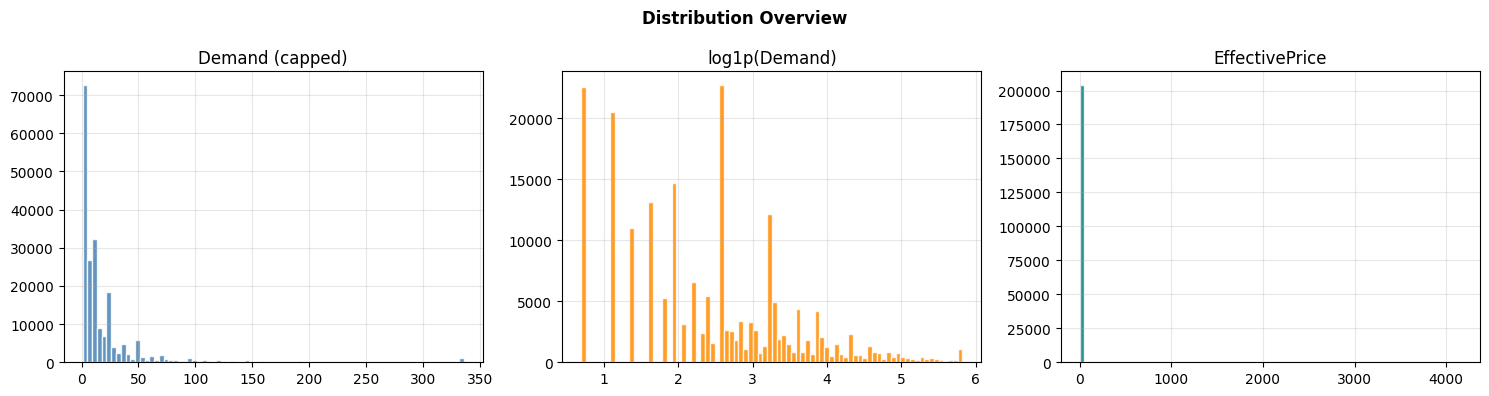

In [5]:
# =============================================================================
# SECTION 4 — OUTLIER CAP + LOG TARGET
# =============================================================================

raw_skew   = float(daily['Demand'].skew())
demand_cap = float(daily['Demand'].quantile(0.995))
daily['Demand'] = daily['Demand'].clip(upper=demand_cap)
daily['LogDemand'] = np.log1p(daily['Demand'])
print(f"Demand skew: raw={raw_skew:.2f}  capped={daily['Demand'].skew():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(daily['Demand'],         bins=80, color='steelblue',  edgecolor='white', alpha=0.85)
axes[0].set_title('Demand (capped)'); axes[0].grid(alpha=0.3)
axes[1].hist(daily['LogDemand'],      bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('log1p(Demand)');   axes[1].grid(alpha=0.3)
axes[2].hist(daily['EffectivePrice'], bins=80, color='teal',       edgecolor='white', alpha=0.85)
axes[2].set_title('EffectivePrice');  axes[2].grid(alpha=0.3)
plt.suptitle('Distribution Overview', fontweight='bold')
safe_show()


In [6]:
# =============================================================================
# SECTION 5 — TIME FEATURES
# =============================================================================

daily['DayOfWeek']  = daily['Date'].dt.dayofweek
daily['Month']      = daily['Date'].dt.month
daily['Quarter']    = daily['Date'].dt.quarter
daily['WeekOfYear'] = daily['Date'].dt.isocalendar().week.astype(int)
daily['IsWeekend']  = daily['DayOfWeek'].isin([5, 6]).astype(int)
daily['IsMonthEnd'] = daily['Date'].dt.is_month_end.astype(int)


In [7]:
# =============================================================================
# SECTION 6 — EVENT FEATURES (calendar-based, no target dependency)
# =============================================================================

daily['EventImpact'] = 0
for s, e in [('2011-11-20','2011-11-28'), ('2011-12-15','2011-12-25')]:
    daily.loc[(daily['Date'] >= s) & (daily['Date'] <= e), 'EventImpact'] = 2
for s, e in [('2011-02-10','2011-02-14'), ('2011-03-28','2011-04-03'),
             ('2011-04-18','2011-04-24'), ('2011-06-15','2011-06-19')]:
    daily.loc[(daily['Date'] >= s) & (daily['Date'] <= e), 'EventImpact'] = 1

_event_dates = pd.to_datetime(['2011-11-25', '2011-12-25'])
def _event_prox(d):
    dists = [abs((d - e).days) for e in _event_dates]
    m = min(dists)
    return float(np.exp(-m / 5)) if m <= 15 else 0.0
daily['EventProximity'] = daily['Date'].apply(_event_prox)


In [8]:
# =============================================================================
# SECTION 7 — SORT BEFORE ALL LAG / ROLLING (mandatory for leakage-free ops)
# =============================================================================

daily = daily.sort_values(['StockCode', 'Date']).reset_index(drop=True)


In [9]:
# =============================================================================
# SECTION 8 — LEAKAGE-FREE LAG & ROLLING FEATURES
#   Every feature uses shift(1) as the minimal offset.
#   Rolling windows operate on the pre-shifted series only.
#   DemandSpike is REMOVED — it uses current Demand directly → target leakage.
# =============================================================================

_g             = daily.groupby('StockCode', sort=False)
shifted_demand = _g['Demand'].shift(1)
shifted_price  = _g['EffectivePrice'].shift(1)

daily['Lag_1']  = shifted_demand
daily['Lag_7']  = _g['Demand'].shift(7)
daily['Lag_14'] = _g['Demand'].shift(14)

def _roll(series, window, func_name):
    return (series
            .groupby(daily['StockCode'], sort=False)
            .transform(lambda x: getattr(x.rolling(window, min_periods=1), func_name)()))

daily['RollingMean_7']  = _roll(shifted_demand, 7,  'mean')
daily['RollingMean_14'] = _roll(shifted_demand, 14, 'mean')
daily['RollingMax_7']   = _roll(shifted_demand, 7,  'max')
daily['RollingStd_7']   = (
    shifted_demand
    .groupby(daily['StockCode'], sort=False)
    .transform(lambda x: x.rolling(7, min_periods=2).std().fillna(0))
)

# Past-only price features
daily['PriceChange']   = (daily['EffectivePrice'] - shifted_price).fillna(0)
daily['PriceMomentum'] = (daily['PriceChange'] /
                          shifted_price.clip(lower=1e-6)).fillna(0).clip(-5, 5)

# Demand momentum (past only)
daily['DemandMomentum'] = (
    daily['Lag_1'] / daily['RollingMean_7'].clip(lower=1e-6)
).clip(0, 5).fillna(1.0)

# Coefficient of variation
daily['DemandCV'] = (
    daily['RollingStd_7'] / daily['RollingMean_7'].clip(lower=1e-6)
).clip(0, 10).fillna(0)

# Days since last recorded sale
daily['DaysSinceLastSale'] = _g['Date'].diff().dt.days.fillna(0).clip(0, 365)

# Revenue — viz only, excluded from model
daily['Revenue'] = daily['Demand'] * daily['EffectivePrice']

# NaN/Inf guard on all numeric columns
for _c in daily.select_dtypes(include=np.number).columns:
    daily[_c] = daily[_c].replace([np.inf, -np.inf], np.nan)


In [10]:
# =============================================================================
# SECTION 9 — LEAKAGE DETECTION (real chronological validation)
# =============================================================================

print("\n--- Leakage Detection ---")

# Rule 1: any feature with |corr| > 0.95 to LogDemand on full dataset
_excl   = {'Demand', 'LogDemand', 'Revenue', 'hist_p10', 'hist_p90'}
_num    = [c for c in daily.select_dtypes(include=np.number).columns if c not in _excl]
_corrs  = daily[_num + ['LogDemand']].corr()['LogDemand'].drop('LogDemand', errors='ignore')
_corrs  = _corrs.replace([np.inf, -np.inf], np.nan).dropna()
_hc     = _corrs[_corrs.abs() > 0.95]
print(f"  High corr with target (>0.95): {_hc.index.tolist() or 'None'}")

# Rule 2: chronological leakage — train a tiny model and measure if out-of-time
#   performance is suspiciously higher than in-time (would indicate leakage)
_n_leak     = len(daily)
_split_leak = int(_n_leak * 0.8)
_Xl         = daily[_num].fillna(0)
_yl         = daily['LogDemand'].fillna(0)
_rf_leak    = RandomForestRegressor(n_estimators=20, max_depth=4,
                                     n_jobs=-1, random_state=SEED)
_rf_leak.fit(_Xl.iloc[:_split_leak], _yl.iloc[:_split_leak])
_r2_train   = r2_score(_yl.iloc[:_split_leak],
                        _rf_leak.predict(_Xl.iloc[:_split_leak]))
_r2_oot     = r2_score(_yl.iloc[_split_leak:],
                        _rf_leak.predict(_Xl.iloc[_split_leak:]))
print(f"  Chrono leakage check — train R²={_r2_train:.3f}  OOT R²={_r2_oot:.3f}")
if _r2_oot > _r2_train + 0.10:
    print("  WARNING: OOT R² > train R² — possible leakage or distribution shift")
else:
    print("  Leakage check passed.")
del _rf_leak, _Xl, _yl



--- Leakage Detection ---
  High corr with target (>0.95): None
  Chrono leakage check — train R²=0.548  OOT R²=0.531
  Leakage check passed.


In [11]:
# =============================================================================
# SECTION 10 — FEATURE REDUNDANCY REMOVAL
#   Protected pricing features are NEVER dropped.
# =============================================================================

PROTECTED = {'EffectivePrice', 'CompetitorPrice', 'PriceDiff',
             'PriceRatio', 'PriceMomentum', 'PriceChange'}

_always_drop = {'Date', 'StockCode', 'AvgPrice', 'MinPrice', 'MaxPrice',
                'Demand', 'Revenue', 'LogDemand', 'hist_p10', 'hist_p90'}
_model_data = daily.drop(columns=[c for c in _always_drop if c in daily.columns]).copy()
_model_data['LogDemand'] = daily['LogDemand'].values

# Drop near-zero variance (skip protected)
_var = _model_data.var(numeric_only=True)
_low_var = [c for c in _var[_var < 1e-6].index if c not in PROTECTED and c != 'LogDemand']
if _low_var:
    print(f"\nDropping near-zero variance: {_low_var}")
    _model_data.drop(columns=_low_var, inplace=True)

# Drop highly correlated pairs (skip protected)
_feat_only = [c for c in _model_data.columns if c not in PROTECTED and c != 'LogDemand']
_cm = _model_data[_feat_only].corr().abs()
_cm = _cm.replace([np.inf, -np.inf], np.nan).fillna(0)
_ut = _cm.where(np.triu(np.ones(_cm.shape, dtype=bool), k=1))
_redundant = [c for c in _ut.columns
              if _ut[c].max() > 0.97 and c not in PROTECTED]
if _redundant:
    print(f"Dropping redundant (corr>0.97): {_redundant}")
    _model_data.drop(columns=_redundant, inplace=True)
else:
    print("No redundant features removed.")

_model_data = _model_data.dropna()

TARGET   = 'LogDemand'
FEATURES = [c for c in _model_data.columns if c != TARGET]

# Re-align daily
daily = daily.loc[_model_data.index].reset_index(drop=True)
_model_data = _model_data.reset_index(drop=True)
X = _model_data[FEATURES].copy()
y = _model_data[TARGET].copy()

# Final NaN/Inf sweep
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y = y.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")
print(f"Modelling rows: {len(X):,}")

# Dependency check — required simulation columns must be in FEATURES
_required_sim_cols = ['EffectivePrice', 'CompetitorPrice', 'PriceDiff', 'PriceRatio',
                      'RollingMean_7']
_missing_sim = [c for c in _required_sim_cols if c not in FEATURES]
if _missing_sim:
    raise RuntimeError(f"Required simulation features missing from FEATURES: {_missing_sim}")
print(f"Simulation dependency check: OK")


Dropping redundant (corr>0.97): ['NumCustomers', 'Quarter', 'WeekOfYear', 'RollingStd_7']

Features (23): ['NumTransactions', 'EffectivePrice', 'PriceRange', 'CompetitorPrice', 'PriceDiff', 'PriceRatio', 'DayOfWeek', 'Month', 'IsWeekend', 'IsMonthEnd', 'EventImpact', 'EventProximity', 'Lag_1', 'Lag_7', 'Lag_14', 'RollingMean_7', 'RollingMean_14', 'RollingMax_7', 'PriceChange', 'PriceMomentum', 'DemandMomentum', 'DemandCV', 'DaysSinceLastSale']
Modelling rows: 175,135
Simulation dependency check: OK


In [12]:
# =============================================================================
# SECTION 11 — STRICT DATE-BASED SPLIT (no row-index leakage)
# =============================================================================

_dates       = daily['Date'].sort_values()
train_cutoff = _dates.quantile(0.70, interpolation='nearest')
val_cutoff   = _dates.quantile(0.80, interpolation='nearest')

train_mask = (daily['Date'] <= train_cutoff).values
val_mask   = ((daily['Date'] > train_cutoff) & (daily['Date'] <= val_cutoff)).values
test_mask  = (daily['Date'] > val_cutoff).values

X_train, y_train = X[train_mask],  y[train_mask]
X_val,   y_val   = X[val_mask],    y[val_mask]
X_test,  y_test  = X[test_mask],   y[test_mask]

assert daily.loc[train_mask, 'Date'].max() < daily.loc[val_mask,  'Date'].min(), "Train/Val overlap"
assert daily.loc[val_mask,  'Date'].max()  < daily.loc[test_mask, 'Date'].min(), "Val/Test overlap"
print(f"\nTrain: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Train ≤ {train_cutoff.date()}  |  Val ≤ {val_cutoff.date()}  |  Test > {val_cutoff.date()}")
print("Split integrity: OK")

if len(X_train) < 100 or len(X_val) < 10 or len(X_test) < 10:
    raise RuntimeError("Insufficient data in one or more splits — relax sparsity thresholds.")



Train: (123586, 23)  Val: (16529, 23)  Test: (35020, 23)
Train ≤ 2011-10-06  |  Val ≤ 2011-10-28  |  Test > 2011-10-28
Split integrity: OK


In [13]:
# =============================================================================
# SECTION 12 — DATE-BLOCK CROSS-VALIDATION (strict, no row-shuffling)
# =============================================================================

def date_block_cv(X_cv, y_cv, dates_cv, n_folds=5):
    """Returns list of (train_idx, val_idx) arrays based on date blocks."""
    unique_dates = np.sort(dates_cv.unique())
    fold_size    = len(unique_dates) // (n_folds + 1)
    if fold_size < 1:
        return []
    folds = []
    for k in range(1, n_folds + 1):
        cutoff   = unique_dates[min(k * fold_size, len(unique_dates) - 1)]
        tr_idx   = np.where(dates_cv <= cutoff)[0]
        va_start = unique_dates[min(k * fold_size, len(unique_dates) - 1)]
        va_end   = unique_dates[min((k + 1) * fold_size, len(unique_dates) - 1)]
        va_idx   = np.where((dates_cv > va_start) & (dates_cv <= va_end))[0]
        if len(tr_idx) > 0 and len(va_idx) > 0:
            folds.append((tr_idx, va_idx))
    return folds

_train_dates = daily.loc[train_mask, 'Date'].reset_index(drop=True)
_cv_folds    = date_block_cv(X_train, y_train, _train_dates, n_folds=5)

def cv_score(model_cls, params, X_cv, y_cv, folds):
    rmse_list, mae_list = [], []
    for tr, va in folds:
        if len(tr) < 10 or len(va) < 5:
            continue
        m = model_cls(**params)
        m.fit(X_cv.iloc[tr], y_cv.iloc[tr])
        p = np.expm1(np.maximum(m.predict(X_cv.iloc[va]), 0))
        a = np.expm1(y_cv.iloc[va].values)
        rmse_list.append(np.sqrt(mean_squared_error(a, p)))
        mae_list.append(mean_absolute_error(a, p))
    if not rmse_list:
        return np.nan, np.nan, np.nan
    return float(np.mean(rmse_list)), float(np.std(rmse_list)), float(np.mean(mae_list))

print("\nDate-block CV (5 folds, train set only):")
_cv_rf_r, _cv_rf_s, _cv_rf_m = cv_score(
    RandomForestRegressor,
    dict(n_estimators=80, max_depth=7, min_samples_leaf=8,
         max_features=0.6, n_jobs=-1, random_state=SEED),
    X_train, y_train, _cv_folds
)
_cv_gb_r, _cv_gb_s, _cv_gb_m = cv_score(
    GradientBoostingRegressor,
    dict(n_estimators=150, max_depth=4, learning_rate=0.06,
         subsample=0.75, min_samples_leaf=12, random_state=SEED),
    X_train, y_train, _cv_folds
)
print(f"  RF  RMSE={_cv_rf_r:.4f} ±{_cv_rf_s:.4f}  MAE={_cv_rf_m:.4f}")
print(f"  GB  RMSE={_cv_gb_r:.4f} ±{_cv_gb_s:.4f}  MAE={_cv_gb_m:.4f}")



Date-block CV (5 folds, train set only):
  RF  RMSE=27.9058 ±1.4202  MAE=10.7828
  GB  RMSE=26.7523 ±1.4736  MAE=10.3865



Unstable features (importance CV > 1.5): ['PriceDiff', 'EventImpact']


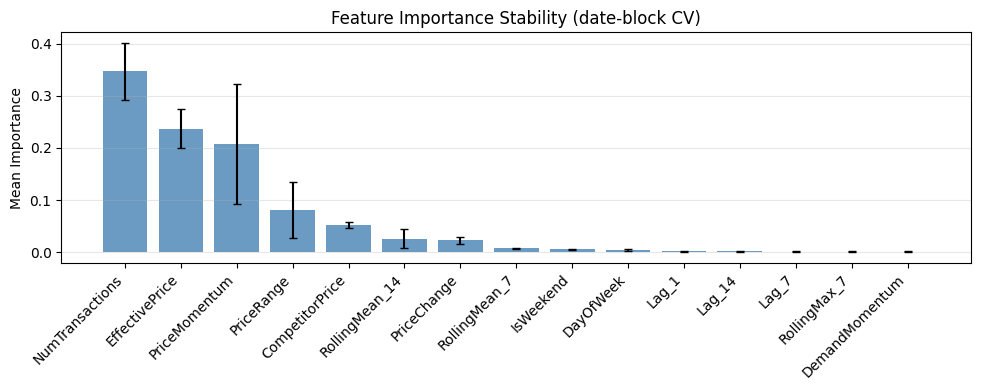

In [14]:
# =============================================================================
# SECTION 13 — FEATURE STABILITY PLOT
# =============================================================================

_fi_folds = []
_rf_stab  = RandomForestRegressor(n_estimators=50, max_depth=6,
                                   n_jobs=-1, random_state=SEED)
for tr, va in _cv_folds:
    if len(tr) < 10:
        continue
    _rf_stab.fit(X_train.iloc[tr], y_train.iloc[tr])
    _fi_folds.append(_rf_stab.feature_importances_)

if _fi_folds:
    _fi_df   = pd.DataFrame(_fi_folds, columns=FEATURES)
    _fi_mean = _fi_df.mean()
    _fi_std  = _fi_df.std().fillna(0)
    _fi_cv   = (_fi_std / (_fi_mean + 1e-9))
    _unstable = _fi_cv[_fi_cv > 1.5].index.tolist()
    print(f"\nUnstable features (importance CV > 1.5): {_unstable or 'None'}")

    _order = _fi_mean.sort_values(ascending=False).index[:min(15, len(FEATURES))]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(_order)), _fi_mean[_order].values,
           yerr=_fi_std[_order].values, color='steelblue', alpha=0.8, capsize=3)
    ax.set_xticks(range(len(_order)))
    ax.set_xticklabels(_order, rotation=45, ha='right')
    ax.set_title('Feature Importance Stability (date-block CV)')
    ax.set_ylabel('Mean Importance'); ax.grid(alpha=0.3, axis='y')
    safe_show()


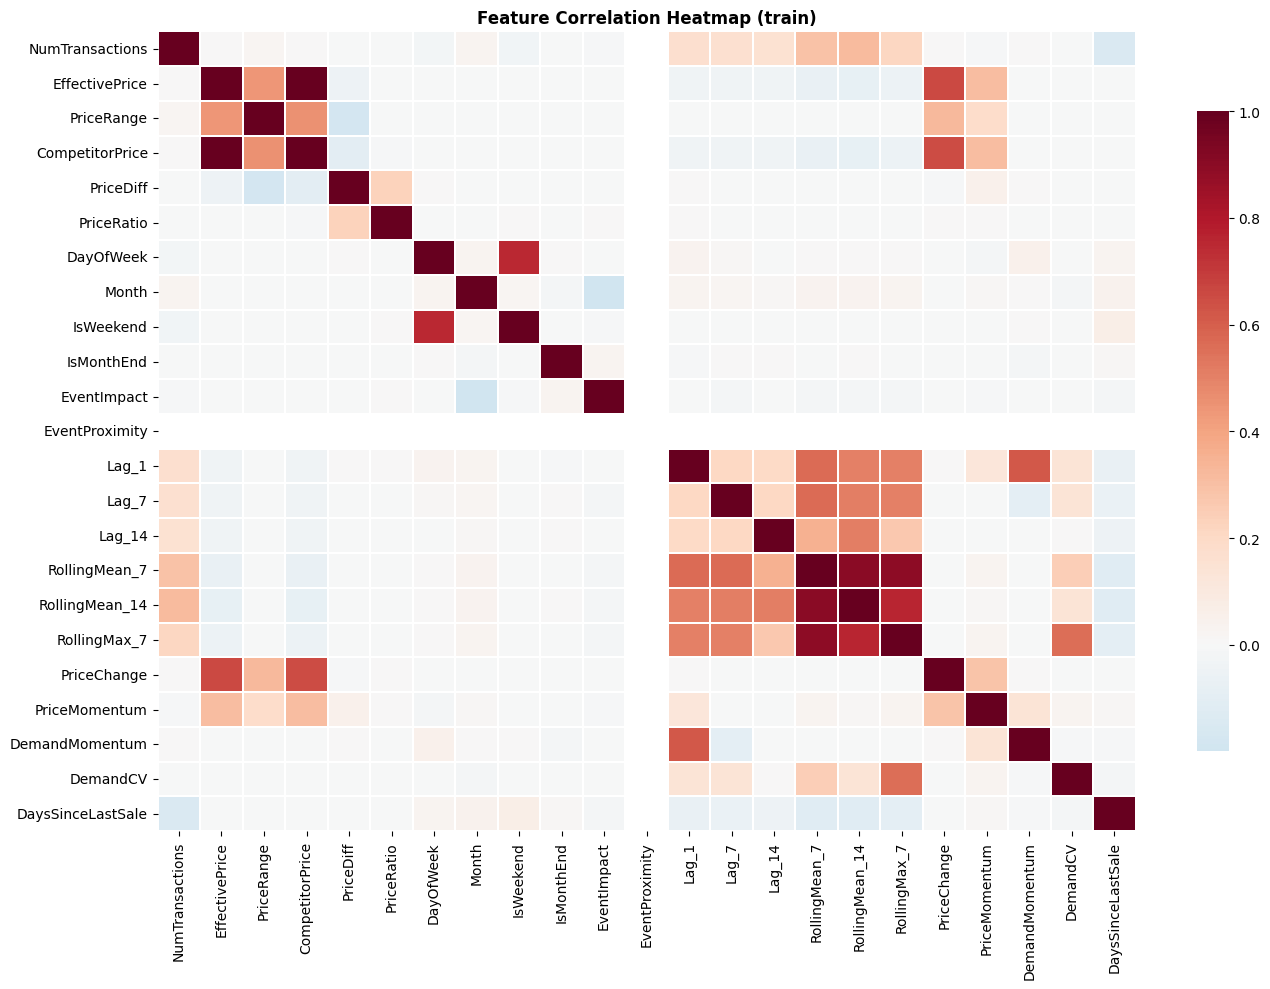

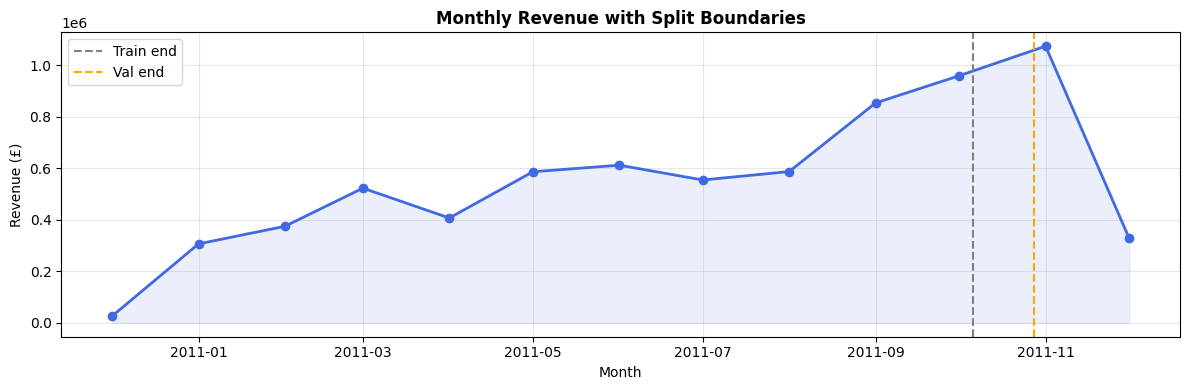

In [15]:
# =============================================================================
# SECTION 14 — CORRELATION HEATMAP & MONTHLY REVENUE
# =============================================================================

_corr_data = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
if _corr_data.shape[1] > 1:
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(_corr_data.corr(), annot=False, cmap='RdBu_r',
                center=0, linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title('Feature Correlation Heatmap (train)', fontweight='bold')
    safe_show()

monthly_rev = (daily.groupby(daily['Date'].dt.to_period('M'))['Revenue']
               .sum().reset_index())
monthly_rev['Date'] = monthly_rev['Date'].dt.to_timestamp()
if len(monthly_rev) > 1:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly_rev['Date'], monthly_rev['Revenue'],
            marker='o', color='royalblue', linewidth=2)
    ax.fill_between(monthly_rev['Date'], monthly_rev['Revenue'],
                    alpha=0.1, color='royalblue')
    ax.axvline(pd.Timestamp(train_cutoff), color='gray',   linestyle='--', label='Train end')
    ax.axvline(pd.Timestamp(val_cutoff),   color='orange', linestyle='--', label='Val end')
    ax.set_title('Monthly Revenue with Split Boundaries', fontweight='bold')
    ax.set_xlabel('Month'); ax.set_ylabel('Revenue (£)')
    ax.legend(); ax.grid(alpha=0.3)
    safe_show()


In [16]:
# =============================================================================
# SECTION 15 — MODEL TRAINING
# =============================================================================

# Naive persistence: use Lag_1 as forecast
_lag1_col = X_test['Lag_1'].clip(lower=0)
naive_preds_log = np.log1p(_lag1_col.fillna(0).values)

baseline_mean = DummyRegressor(strategy='mean')
baseline_mean.fit(X_train, y_train)

rf = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=8,
    max_features=0.6, n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)

# XGBoost — version-safe kwargs
_xgb_kwargs = dict(
    n_estimators=1000, max_depth=6, learning_rate=0.04,
    subsample=0.75, colsample_bytree=0.7, min_child_weight=8,
    reg_alpha=0.5, reg_lambda=2.0, seed=SEED,
    n_jobs=-1, verbosity=0
)
try:
    xgb_model = xgb.XGBRegressor(**_xgb_kwargs, early_stopping_rounds=30)
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
except TypeError:
    # Older XGBoost API
    xgb_model = xgb.XGBRegressor(**_xgb_kwargs)
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)], verbose=False,
                  early_stopping_rounds=30)

gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.04,
    subsample=0.75, min_samples_leaf=12, random_state=SEED
)
gb.fit(X_train, y_train)

if LGBM_AVAILABLE:
    try:
        lgbm_model = lgb.LGBMRegressor(
            n_estimators=1000, max_depth=6, learning_rate=0.04,
            num_leaves=63, subsample=0.75, colsample_bytree=0.7,
            reg_alpha=0.5, reg_lambda=2.0,
            random_state=SEED, n_jobs=-1, verbose=-1
        )
        lgbm_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False),
                       lgb.log_evaluation(-1)]
        )
    except Exception as _e:
        print(f"LightGBM training failed ({_e}); skipping.")
        LGBM_AVAILABLE = False


In [17]:
# =============================================================================
# SECTION 16 — METRICS
# =============================================================================

def _safe_r2(a, p):
    if np.std(a) < 1e-8:
        return 0.0
    return float(r2_score(a, p))

def smape(a, p):
    denom = (np.abs(a) + np.abs(p)) / 2 + 1e-8
    return float(np.mean(np.abs(a - p) / denom) * 100)

def wape(a, p):
    total = np.sum(np.abs(a)) + 1e-8
    return float(np.sum(np.abs(a - p)) / total * 100)

def bias(a, p):
    return float(np.mean(p - a))

def forecast_stability(p):
    """Mean absolute change between consecutive predictions."""
    if len(p) < 2:
        return np.nan
    return float(np.mean(np.abs(np.diff(p))))

def evaluate_log_model(log_preds, y_t_log):
    lp   = np.nan_to_num(np.maximum(log_preds, 0), nan=0, posinf=0, neginf=0)
    pred = np.expm1(lp)
    act  = np.expm1(y_t_log.values)
    pred = np.nan_to_num(pred, nan=0, posinf=demand_cap, neginf=0)
    act  = np.nan_to_num(act,  nan=0, posinf=demand_cap, neginf=0)
    return dict(
        log_preds = lp,
        preds     = pred,
        rmse      = float(np.sqrt(mean_squared_error(act, pred))),
        mae       = float(mean_absolute_error(act, pred)),
        r2        = _safe_r2(act, pred),
        smape     = smape(act, pred),
        wape      = wape(act, pred),
        bias      = bias(act, pred),
        stability = forecast_stability(pred),
    )


In [18]:
# =============================================================================
# SECTION 17 — EVALUATE ALL MODELS
# =============================================================================

results = {}

results['Naive Persistence'] = dict(model=None,
    **evaluate_log_model(naive_preds_log, y_test))
results['Mean Baseline'] = dict(model=baseline_mean,
    **evaluate_log_model(np.maximum(baseline_mean.predict(X_test), 0), y_test))

for _name, _mdl in [('Random Forest', rf), ('XGBoost', xgb_model),
                     ('Gradient Boosting', gb)]:
    results[_name] = dict(model=_mdl,
        **evaluate_log_model(_mdl.predict(X_test), y_test))

if LGBM_AVAILABLE:
    results['LightGBM'] = dict(model=lgbm_model,
        **evaluate_log_model(lgbm_model.predict(X_test), y_test))

# Ensemble (trained models only)
_lkeys = [k for k in results
          if k not in ('Naive Persistence', 'Mean Baseline')
          and results[k]['model'] is not None]
if _lkeys:
    _lp_ens = np.mean([results[k]['log_preds'] for k in _lkeys], axis=0)
    results['Ensemble'] = dict(model=None,
        **evaluate_log_model(_lp_ens, y_test))


In [19]:
# =============================================================================
# SECTION 18 — METRICS TABLE
# =============================================================================

_BASELINES = {'Naive Persistence', 'Mean Baseline', 'Ensemble'}
print(f"\n{'Model':<22} {'RMSE':>9} {'MAE':>9} {'R²':>7} {'sMAPE%':>8} "
      f"{'WAPE%':>7} {'Bias':>8} {'Stab':>8}")
print("-" * 80)
for _n, _r in results.items():
    _tag = "" if _n in _BASELINES else " <--"
    print(f"{_n:<22} {_r['rmse']:>9.4f} {_r['mae']:>9.4f} {_r['r2']:>7.4f} "
          f"{_r['smape']:>8.2f} {_r['wape']:>7.2f} {_r['bias']:>8.2f} "
          f"{_r['stability']:>8.2f}{_tag}")

_solo = {k: v for k, v in results.items() if k not in _BASELINES}
if not _solo:
    raise RuntimeError("No trained models available for selection.")
best_name  = min(_solo, key=lambda k: _solo[k]['rmse'])
best_res   = results[best_name]
best_model = best_res['model']
best_preds = best_res['preds']
best_lp    = best_res['log_preds']

naive_rmse  = results['Naive Persistence']['rmse']
_lift       = (naive_rmse - best_res['rmse']) / (naive_rmse + 1e-8) * 100
print(f"\nBest: {best_name}  RMSE={best_res['rmse']:.4f}  R²={best_res['r2']:.4f}  "
      f"RMSE lift vs naive: {_lift:.1f}%")



Model                       RMSE       MAE      R²   sMAPE%   WAPE%     Bias     Stab
--------------------------------------------------------------------------------
Naive Persistence        47.8610   22.4399 -0.3376    88.56   98.11     0.13    22.78
Mean Baseline            43.3904   19.0863 -0.0994    92.28   83.45   -13.05     0.00
Random Forest            26.9430   11.5673  0.5761    59.36   50.57    -2.55    14.31 <--
XGBoost                  26.4592   11.3731  0.5912    58.70   49.73    -2.73    14.92 <--
Gradient Boosting        26.6129   11.3490  0.5864    58.48   49.62    -2.75    15.20 <--
LightGBM                 26.4426   11.3916  0.5917    58.64   49.81    -2.53    15.31 <--
Ensemble                 26.3494   11.2845  0.5946    58.49   49.34    -2.73    14.76

Best: LightGBM  RMSE=26.4426  R²=0.5917  RMSE lift vs naive: 44.8%


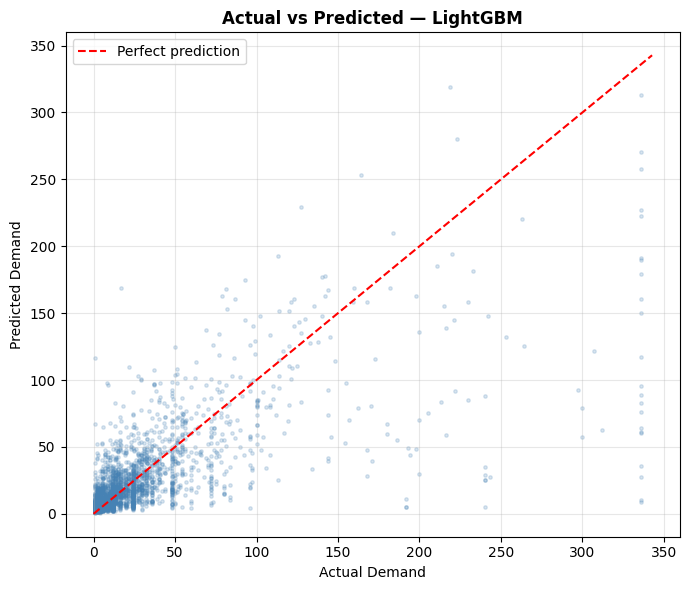

In [20]:
# =============================================================================
# SECTION 19 — ACTUAL VS PREDICTED
# =============================================================================

actual_orig = np.expm1(y_test.values)
n_plot      = min(3000, len(actual_orig))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(actual_orig[:n_plot], best_preds[:n_plot],
           alpha=0.2, s=6, color='steelblue')
_lim = [0, max(actual_orig[:n_plot].max(), best_preds[:n_plot].max()) * 1.02]
ax.plot(_lim, _lim, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Demand'); ax.set_ylabel('Predicted Demand')
ax.set_title(f'Actual vs Predicted — {best_name}', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
safe_show()


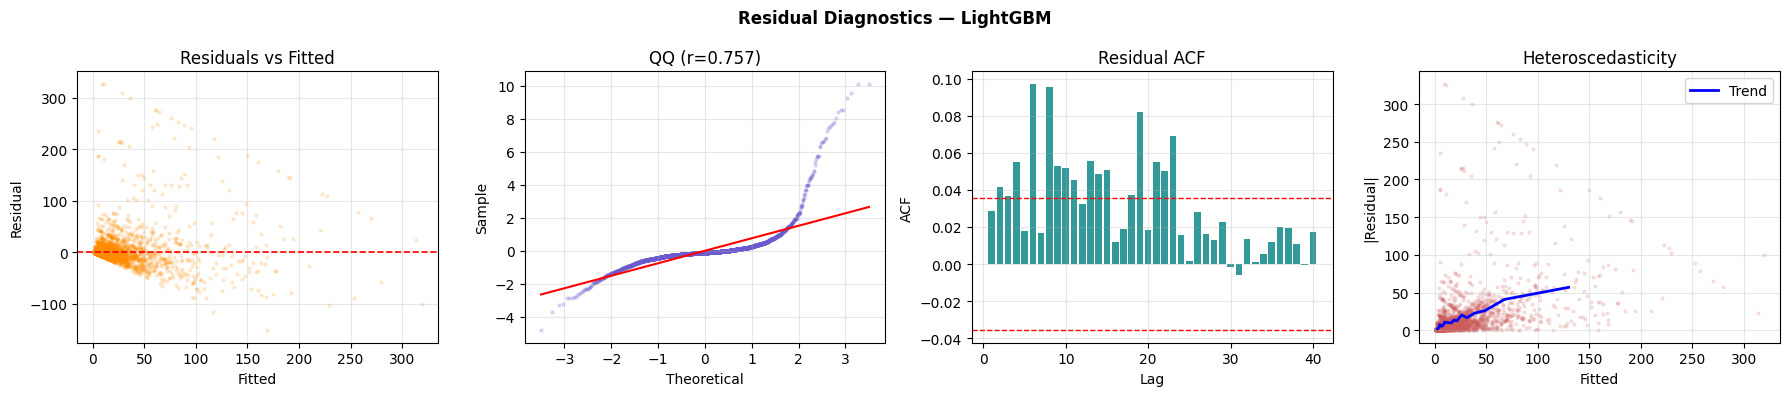


Residual diagnostics:
  QQ r²                  : 0.5725
  |Res|-Fitted corr      : 0.4433
  ACF lags >2σ (40 max): 16


In [21]:
# =============================================================================
# SECTION 20 — RESIDUAL DIAGNOSTICS
# =============================================================================

if n_plot >= 30:
    residuals     = actual_orig[:n_plot] - best_preds[:n_plot]
    residuals     = np.nan_to_num(residuals, nan=0, posinf=0, neginf=0)
    std_residuals = (residuals - residuals.mean()) / (residuals.std() + 1e-8)

    fig = plt.figure(figsize=(18, 4))
    gs  = gridspec.GridSpec(1, 4, figure=fig)
    fig.suptitle(f'Residual Diagnostics — {best_name}', fontweight='bold')

    ax1 = fig.add_subplot(gs[0])
    ax1.scatter(best_preds[:n_plot], residuals, alpha=0.15, s=4, color='darkorange')
    ax1.axhline(0, color='red', linewidth=1.2, linestyle='--')
    ax1.set_xlabel('Fitted'); ax1.set_ylabel('Residual')
    ax1.set_title('Residuals vs Fitted'); ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1])
    try:
        (osm, osr), (slope, intercept, r_qq) = scipy_stats.probplot(
            std_residuals, dist='norm')
        ax2.scatter(osm, osr, alpha=0.2, s=4, color='slateblue')
        ax2.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
        ax2.set_title(f'QQ (r={r_qq:.3f})')
    except Exception:
        r_qq = np.nan
        ax2.set_title('QQ — insufficient data')
    ax2.set_xlabel('Theoretical'); ax2.set_ylabel('Sample'); ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[2])
    max_lag   = min(40, n_plot // 4)
    conf_bound = 1.96 / np.sqrt(max(n_plot, 1))
    acf_vals  = []
    for _lag in range(1, max_lag + 1):
        if _lag >= len(residuals):
            break
        _cm = np.corrcoef(residuals[_lag:], residuals[:-_lag])
        _v  = float(_cm[0, 1]) if _cm.shape == (2, 2) and np.isfinite(_cm[0, 1]) else 0.0
        acf_vals.append(_v)
    if acf_vals:
        ax3.bar(range(1, len(acf_vals) + 1), acf_vals, color='teal', alpha=0.8)
        ax3.axhline( conf_bound, color='red', linestyle='--', linewidth=1)
        ax3.axhline(-conf_bound, color='red', linestyle='--', linewidth=1)
    ax3.set_xlabel('Lag'); ax3.set_ylabel('ACF')
    ax3.set_title('Residual ACF'); ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[3])
    ax4.scatter(best_preds[:n_plot], np.abs(residuals),
                alpha=0.15, s=4, color='indianred')
    _bins_p  = np.percentile(best_preds[:n_plot], np.linspace(5, 95, 20))
    _bidx    = np.digitize(best_preds[:n_plot], _bins_p)
    _bmean_y = [np.abs(residuals)[_bidx == b].mean()
                for b in range(1, len(_bins_p) + 1)
                if (_bidx == b).sum() > 0]
    _bmean_x = [best_preds[:n_plot][_bidx == b].mean()
                for b in range(1, len(_bins_p) + 1)
                if (_bidx == b).sum() > 0]
    if _bmean_x:
        ax4.plot(_bmean_x, _bmean_y, 'b-', linewidth=2, label='Trend')
        ax4.legend()
    ax4.set_xlabel('Fitted'); ax4.set_ylabel('|Residual|')
    ax4.set_title('Heteroscedasticity'); ax4.grid(alpha=0.3)

    safe_show()

    bp_corr = float(np.corrcoef(best_preds[:n_plot],
                                 np.abs(residuals))[0, 1]) if n_plot >= 3 else np.nan
    sig_acf = sum(1 for a in acf_vals if abs(a) > conf_bound)
    print(f"\nResidual diagnostics:")
    print(f"  QQ r²                  : {r_qq**2:.4f}" if np.isfinite(r_qq) else "  QQ: n/a")
    print(f"  |Res|-Fitted corr      : {bp_corr:.4f}" if np.isfinite(bp_corr) else "  Heterosc: n/a")
    print(f"  ACF lags >2σ ({max_lag} max): {sig_acf}")
else:
    r_qq, bp_corr, sig_acf, conf_bound, acf_vals, max_lag = (
        np.nan, np.nan, 0, 0.1, [], 0)
    print("Residual diagnostics skipped (insufficient test rows).")


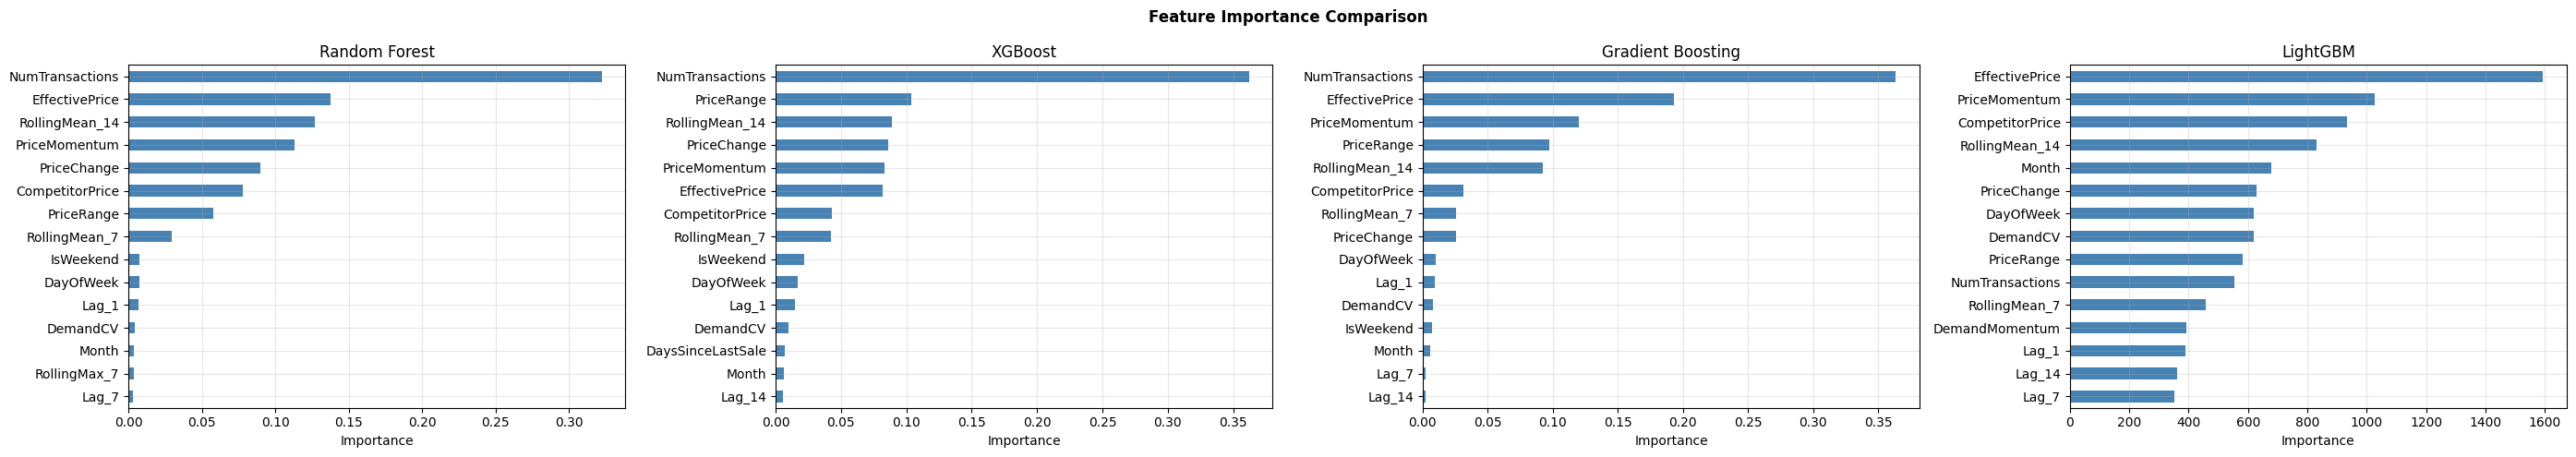

In [22]:
# =============================================================================
# SECTION 21 — FEATURE IMPORTANCE
# =============================================================================

_fi_eligible = {k: v for k, v in results.items()
                if v.get('model') is not None
                and hasattr(v['model'], 'feature_importances_')
                and k not in _BASELINES}

if _fi_eligible:
    _nfi = len(_fi_eligible)
    fig, axes = plt.subplots(1, _nfi, figsize=(7 * _nfi, 5))
    if _nfi == 1:
        axes = [axes]
    fig.suptitle('Feature Importance Comparison', fontweight='bold')
    for _ax, (_nm, _rv) in zip(axes, _fi_eligible.items()):
        _fi = pd.Series(_rv['model'].feature_importances_,
                        index=FEATURES).sort_values(ascending=False)
        _fi.head(15).plot(kind='barh', ax=_ax, color='steelblue')
        _ax.invert_yaxis()
        _ax.set_title(_nm); _ax.set_xlabel('Importance'); _ax.grid(alpha=0.3)
    safe_show()


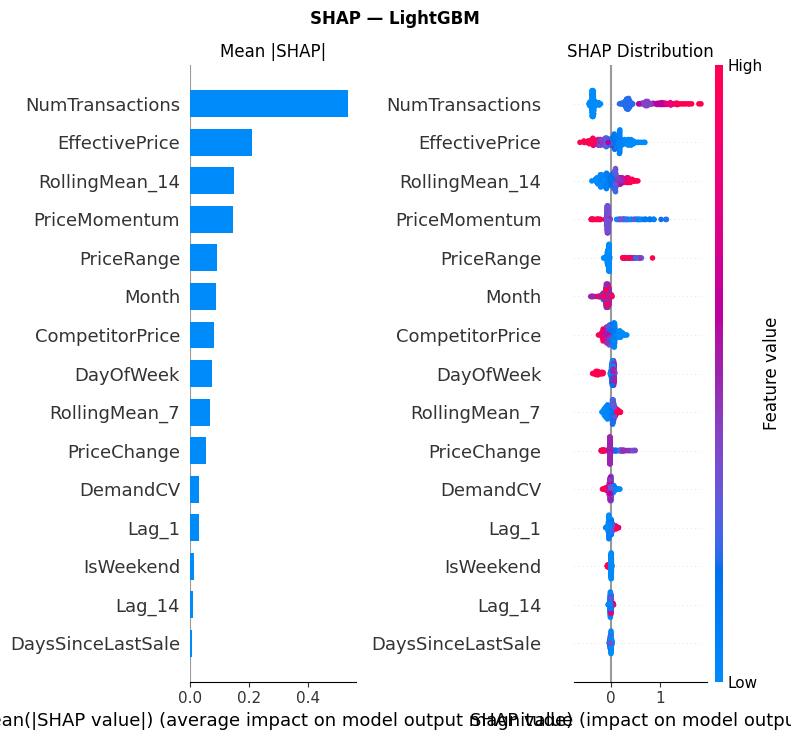

In [23]:
# =============================================================================
# SECTION 22 — SHAP (memory-safe, backend-safe, graceful fallback)
# =============================================================================

if SHAP_AVAILABLE and best_model is not None:
    _shap_n = min(300, len(X_test))
    if _shap_n >= 10:
        try:
            _ss = X_test.sample(_shap_n, random_state=SEED).reset_index(drop=True)
            _ss = _ss.replace([np.inf, -np.inf], np.nan).fillna(0)
            _ex = shap.TreeExplainer(best_model, feature_perturbation='tree_path_dependent')
            _sv = _ex.shap_values(_ss)
            # Some models return list (multi-output) — take first
            if isinstance(_sv, list):
                _sv = _sv[0]
            if _sv is not None and _sv.shape == _ss.shape:
                fig, axes = plt.subplots(1, 2, figsize=(15, 5))
                fig.suptitle(f'SHAP — {best_name}', fontweight='bold')
                plt.sca(axes[0])
                shap.summary_plot(_sv, _ss, plot_type='bar',
                                  show=False, max_display=15)
                axes[0].set_title('Mean |SHAP|')
                plt.sca(axes[1])
                shap.summary_plot(_sv, _ss, show=False, max_display=15)
                axes[1].set_title('SHAP Distribution')
                safe_show()
            else:
                print("SHAP values shape mismatch — skipping plots.")
        except Exception as _se:
            print(f"SHAP failed ({_se}) — skipping.")
    else:
        print("SHAP skipped — insufficient test samples.")


In [24]:
# =============================================================================
# SECTION 23 — PRICE ELASTICITY (product-wise, stable subsets only)
# =============================================================================

test_daily = daily[test_mask].copy().reset_index(drop=True)
test_daily['Demand_pred'] = best_preds

MIN_ELAST_OBS   = 8    # minimum valid arc pairs per product
MIN_PRICE_RANGE = 0.02  # minimum observed ΔP / P_avg to count as meaningful

def compute_arc_elasticity(group):
    g     = group.sort_values('Date')
    dP    = g['EffectivePrice'].diff()
    dQ    = g['Demand_pred'].diff()
    P_avg = ((g['EffectivePrice'] + g['EffectivePrice'].shift(1)) / 2).clip(lower=1e-4)
    Q_avg = ((g['Demand_pred']    + g['Demand_pred'].shift(1))    / 2).clip(lower=1e-4)
    # Require meaningful price movement relative to average price
    valid = (
        (P_avg > 0.05) &
        (Q_avg > 0.05) &
        (dP.abs() / P_avg > MIN_PRICE_RANGE)
    )
    if valid.sum() < 2:
        return pd.Series({'median_e': np.nan, 'n': 0, 'price_std': np.nan})
    e = (dQ[valid] / Q_avg[valid]) / (dP[valid] / P_avg[valid])
    e = e.replace([np.inf, -np.inf], np.nan).dropna()
    e = e[e.between(-15, 15)]
    if len(e) < 2:
        return pd.Series({'median_e': np.nan, 'n': 0,
                          'price_std': g['EffectivePrice'].std()})
    return pd.Series({
        'median_e':  float(e.median()),
        'n':         int(len(e)),
        'price_std': float(g['EffectivePrice'].std()),
    })

prod_elast = (test_daily.groupby('StockCode')
              .apply(compute_arc_elasticity)
              .reset_index())
prod_elast = prod_elast.dropna(subset=['median_e'])
prod_elast = prod_elast[prod_elast['n'] >= MIN_ELAST_OBS]
# Remove products with near-constant price (unreliable elasticity)
prod_elast = prod_elast[prod_elast['price_std'].fillna(0) > 1e-4]

if len(prod_elast) == 0:
    print("\nNo products with sufficient price variation for elasticity — using fallback e=-1.2")
    abs_med_e = 1.2
    median_e  = -1.2
    elast_vals = pd.Series([-1.2])
else:
    elast_vals = prod_elast['median_e']
    median_e   = float(elast_vals.median())
    abs_med_e  = abs(median_e)
    print(f"\nElasticity: n={len(prod_elast)} products  median={median_e:.4f}  |e|={abs_med_e:.4f}")
    print(f"  Elastic (|e|>1): {(elast_vals.abs() > 1).mean()*100:.1f}%  "
          f"Inelastic: {(elast_vals.abs() <= 1).mean()*100:.1f}%")
    if abs_med_e > 1:
        print("  Elastic — price cuts likely increase revenue")
    else:
        print("  Inelastic — moderate price increases viable")



Elasticity: n=341 products  median=-0.3741  |e|=0.3741
  Elastic (|e|>1): 58.7%  Inelastic: 41.3%
  Inelastic — moderate price increases viable


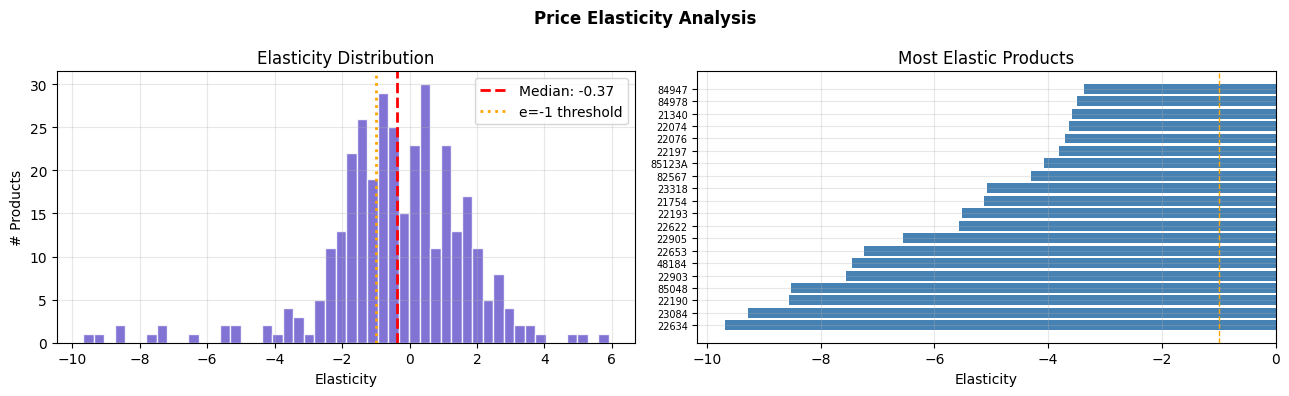

In [25]:
# =============================================================================
# SECTION 24 — ELASTICITY PLOTS (guarded)
# =============================================================================

if len(prod_elast) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Price Elasticity Analysis', fontweight='bold')

    elast_vals.hist(bins=min(50, len(elast_vals)),
                    ax=axes[0], color='slateblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(median_e, color='red',    linestyle='--', linewidth=2,
                    label=f'Median: {median_e:.2f}')
    axes[0].axvline(-1, color='orange', linestyle=':', linewidth=2,
                    label='e=-1 threshold')
    axes[0].set_title('Elasticity Distribution')
    axes[0].set_xlabel('Elasticity'); axes[0].set_ylabel('# Products')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    _top = prod_elast.nsmallest(min(20, len(prod_elast)), 'median_e')
    if len(_top) > 0:
        axes[1].barh(range(len(_top)), _top['median_e'].values,
                     color=['steelblue' if v < -1 else 'salmon'
                            for v in _top['median_e']])
        axes[1].set_yticks(range(len(_top)))
        axes[1].set_yticklabels(_top['StockCode'].astype(str), fontsize=7)
        axes[1].axvline(-1, color='orange', linestyle='--', linewidth=1)
        axes[1].set_title('Most Elastic Products')
        axes[1].set_xlabel('Elasticity'); axes[1].grid(alpha=0.3)

    safe_show()


In [26]:
# =============================================================================
# SECTION 25 — SIMULATION ENGINE
#   - constrained to observed historical price bounds per product
#   - robust to missing/constant competitor price
#   - blended ML + calibrated power-law decay → interior revenue maximum
# =============================================================================

_sim_elast = np.clip(abs_med_e, 0.8, 2.5)

# Build a lookup for historical price bounds (used to constrain sim range)
_price_lb = daily.groupby('StockCode')['EffectivePrice'].quantile(0.10).to_dict()
_price_ub = daily.groupby('StockCode')['EffectivePrice'].quantile(0.90).to_dict()

def _safe_comp_price(row):
    """Return competitor price; fall back to EffectivePrice if invalid."""
    cp = float(row.get('CompetitorPrice', np.nan))
    if not np.isfinite(cp) or cp <= 0:
        cp = float(row.get('EffectivePrice', 1.0))
    return max(cp, 1e-4)

def simulate_demand(model, base_row: pd.Series,
                    price_range: np.ndarray) -> np.ndarray:
    base_ep    = max(float(base_row.get('EffectivePrice', 1.0)), 1e-4)
    comp_price = _safe_comp_price(base_row)
    base_q     = max(float(base_row.get('RollingMean_7', 1.0)), 1e-4)

    rows = []
    for p in price_range:
        r = base_row.copy()
        r['EffectivePrice'] = p
        r['CompetitorPrice'] = comp_price          # held constant in sim
        r['PriceDiff']       = p - comp_price
        r['PriceRatio']      = p / comp_price
        r['PriceChange']     = p - base_ep
        r['PriceMomentum']   = (p - base_ep) / base_ep
        rows.append(r)

    # Build sim DataFrame and fill only FEATURES columns
    sim_df = pd.DataFrame(rows)[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
    log_p  = np.nan_to_num(np.maximum(model.predict(sim_df), 0), nan=0)
    ml_d   = np.expm1(log_p)

    # Calibrated power-law decay
    p_ratio  = price_range / base_ep
    econ_d   = base_q * (p_ratio ** (-_sim_elast))
    blended  = 0.60 * ml_d + 0.40 * econ_d
    return np.clip(np.nan_to_num(blended, nan=0), 0, base_q * 12)


def find_optimal_price(model, base_row: pd.Series,
                       stock_code: str, n_points: int = 120):
    ep    = max(float(base_row.get('EffectivePrice', 1.0)), 1e-4)
    p_lo  = max(_price_lb.get(stock_code, ep * 0.70), ep * 0.60)
    p_hi  = min(_price_ub.get(stock_code, ep * 1.30), ep * 1.40)
    if p_hi <= p_lo:
        p_lo, p_hi = ep * 0.70, ep * 1.30
    pr      = np.linspace(p_lo, p_hi, n_points)
    demand  = simulate_demand(model, base_row, pr)
    revenue = pr * demand
    idx     = int(np.argmax(revenue))
    return pr[idx], demand[idx], revenue[idx], pr, demand, revenue


In [27]:
# =============================================================================
# SECTION 26 — OPTIMAL PRICING TABLE (UPDATED VERSION)
# One Future Optimal Price Per Product
# =============================================================================

# Select rows with valid context
_valid_test = X_test[
    (X_test['RollingMean_7'] > 1.0) &
    (X_test['EffectivePrice'] > 0.5)
].copy()

if len(_valid_test) < 3:
    print("\nInsufficient valid test rows for pricing simulation.")

else:

    # -------------------------------------------------------------------------
    # STEP 1 — Attach metadata from original dataframe
    # -------------------------------------------------------------------------
    _meta = daily.loc[_valid_test.index, ['Date', 'StockCode']].copy()

    # Ensure proper datetime format
    _meta['Date'] = pd.to_datetime(_meta['Date'])

    # -------------------------------------------------------------------------
    # STEP 2 — Keep ONLY latest row per product
    # -------------------------------------------------------------------------
    _latest_meta = (
        _meta
        .sort_values('Date')
        .groupby('StockCode')
        .tail(1)
    )

    # Get corresponding feature rows
    _rows_for_table = _valid_test.loc[_latest_meta.index]

    # -------------------------------------------------------------------------
    # STEP 3 — Sample product demonstration
    # -------------------------------------------------------------------------
    _sample_idx = _rows_for_table.index[len(_rows_for_table) // 2]

    _sample_row = _rows_for_table.loc[_sample_idx].copy()

    _sample_sc = daily.loc[_sample_idx, 'StockCode']
    _sample_dt = daily.loc[_sample_idx, 'Date']

    _base_ep = float(_sample_row['EffectivePrice'])

    # Run optimization
    _opt_p, _opt_d, _opt_r, _pr, _sim_d, _sim_r = find_optimal_price(
        best_model,
        _sample_row,
        _sample_sc
    )

    _is_bnd = (_opt_p == _pr[0]) or (_opt_p == _pr[-1])

    print(f"\nSample Product ({_sample_sc}) Pricing:")
    print(f"  Date:           {str(_sample_dt)[:10]}")
    print(f"  Current Price:  {_base_ep:.2f}")
    print(f"  Optimal Price:  {_opt_p:.2f}  "
          f"({'up' if _opt_p > _base_ep else 'down'} "
          f"{abs(_opt_p/_base_ep - 1)*100:.1f}%)")

    print(f"  Demand:         {_opt_d:.2f}")
    print(f"  Revenue:        {_opt_r:.2f}")
    print(f"  Boundary-stuck: {_is_bnd}")

    # -------------------------------------------------------------------------
    # STEP 4 — Final Optimization Table
    # -------------------------------------------------------------------------
    print(
        f"\n{'i':>3} "
        f"{'Date':<12} "
        f"{'Stock':<12} "
        f"{'Curr£':>7} "
        f"{'Opt£':>7} "
        f"{'Δ%':>7} "
        f"{'Demand':>10} "
        f"{'Revenue':>10} "
        f"{'Interior':>10}"
    )

    print("-" * 95)

    # Sort by stock code for readability
    _latest_meta_sorted = _latest_meta.sort_values('StockCode')

    # -------------------------------------------------------------------------
    # STEP 5 — Run ONE optimization per product
    # -------------------------------------------------------------------------
    for _ii, (_idx, _meta_row) in enumerate(_latest_meta_sorted.iterrows()):

        try:

            # Feature row
            _row = _rows_for_table.loc[_idx].copy()

            # Metadata
            _sc_i = _meta_row['StockCode']
            _dt_i = str(_meta_row['Date'])[:10]

            # Current price
            _bp = float(_row['EffectivePrice'])

            # Run optimization
            _op, _od, _orv, _pr_i, _, _ = find_optimal_price(
                best_model,
                _row,
                _sc_i
            )

            # Percentage price change
            _pct = ((_op - _bp) / (_bp + 1e-8)) * 100

            # Check if optimum is interior
            _int = not ((_op == _pr_i[0]) or (_op == _pr_i[-1]))

            # Print row
            print(
                f"{_ii:>3} "
                f"{_dt_i:<12} "
                f"{str(_sc_i):<12} "
                f"{_bp:>7.2f} "
                f"{_op:>7.2f} "
                f"{_pct:>+7.1f} "
                f"{_od:>10.2f} "
                f"{_orv:>10.2f} "
                f"{str(_int):>10}"
            )

        except Exception as _pe:

            print(
                f"{_ii:>3} "
                f"{str(_meta_row['Date'])[:10]:<12} "
                f"{str(_meta_row['StockCode']):<12} "
                f"simulation error: {_pe}"
            )


Sample Product (20615) Pricing:
  Date:           2011-12-08
  Current Price:  0.75
  Optimal Price:  0.96  (up 28.2%)
  Demand:         13.22
  Revenue:        12.72
  Boundary-stuck: False

  i Date         Stock          Curr£    Opt£      Δ%     Demand    Revenue   Interior
-----------------------------------------------------------------------------------------------


TypeError: '<' not supported between instances of 'str' and 'int'

In [ ]:
# ==========================================================================
# SECTION 27 — PRICING CURVES
# ==========================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Pricing Curves — {best_name} (product {_sample_sc})',
             fontweight='bold')

axes[0].plot(_pr, _sim_d, color='royalblue', linewidth=2)
axes[0].axvline(_base_ep, color='gray',  linestyle='--', linewidth=1.4,
                label=f'Current: {_base_ep:.2f}')
axes[0].axvline(_opt_p,   color='green', linestyle='--', linewidth=1.4,
                label=f'Optimal: {_opt_p:.2f}')
axes[0].set_title('Demand vs Price')
axes[0].set_xlabel('Price (£)'); axes[0].set_ylabel('Demand')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(_pr, _sim_r, color='darkorange', linewidth=2)
axes[1].axvline(_opt_p, color='green', linestyle='--', linewidth=1.4,
                label=f'Optimal: {_opt_p:.2f}')
axes[1].scatter([_opt_p], [_opt_r], color='red', zorder=5, s=80,
                label=f'Max: £{_opt_r:.1f}')
axes[1].set_title('Revenue vs Price')
axes[1].set_xlabel('Price (£)'); axes[1].set_ylabel('Revenue (£)')
axes[1].legend(); axes[1].grid(alpha=0.3)

safe_show()


In [ ]:
# =============================================================================
# SECTION 28 — BUSINESS INSIGHTS
# =============================================================================

print("\n" + "=" * 58)
print("BUSINESS INSIGHTS")
print("=" * 58)

if len(prod_elast) > 0:
    _pct_e = (prod_elast['median_e'] < -1).mean() * 100
    _pct_i = ((prod_elast['median_e'] >= -1) &
               (prod_elast['median_e'] <   0)).mean() * 100
    print(f"  Elastic products (|e|>1)    : {_pct_e:.1f}%")
    print(f"  Inelastic products (|e|<1)  : {_pct_i:.1f}%")
print(f"  Median |elasticity|         : {abs_med_e:.2f}")

if abs_med_e > 1.5:
    print("  Highly elastic — price reductions likely grow revenue.")
elif abs_med_e > 1.0:
    print("  Elastic — targeted discounts should lift revenue.")
else:
    print("  Inelastic — moderate price increases viable.")

print(f"\n  Naive persistence RMSE: {naive_rmse:.4f}")
print(f"  Best model RMSE       : {best_res['rmse']:.4f}  (lift: {_lift:.1f}%)")
print(f"  Best model sMAPE      : {best_res['smape']:.2f}%")
print(f"  Best model WAPE       : {best_res['wape']:.2f}%")
print(f"  Best model Bias       : {best_res['bias']:.4f}")
print(f"  Best model R²         : {best_res['r2']:.4f}")

if best_res['r2'] >= 0.80:
    print("  High confidence in forecasts.")
elif best_res['r2'] >= 0.55:
    print("  Moderate confidence — use directionally.")
else:
    print("  Low R² — check feature quality and data volume.")

if np.isfinite(r_qq):
    print(f"\n  Residual normality (QQ r²): {r_qq**2:.4f}")
if np.isfinite(bp_corr):
    print(f"  Heteroscedasticity corr   : {bp_corr:.4f}")
if acf_vals:
    print(f"  ACF lags >2σ ({max_lag} checked): {sig_acf}")
    if sig_acf > 5:
        print("  Significant autocorrelation — consider additional lag features.")

print("=" * 58)
print("PIPELINE COMPLETE")
print("=" * 58)
